# Predicting heart disease using machine learning

This project is course-based and focuses on using various Python-based machine learning and data science libraries to build a machine learning model. The model's goal is to predict whether someone has heart disease based on their medical attributes.

We'll take the following approach:

1. Problem Definition
2. Data
3. Evaluation
4. Features
5. Modeling
6. Experimentation

## 1. Problem Definition
The prolem we aim to solve is:
> Given clinical parameters about a patient, can we predict whether or not they have heart disease?

## 2. Data
The original data comes from the Cleveland dataset, which is available at the UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/45/heart+disease

Another version of it is available on Kaggle.https://www.kaggle.com/datasets/sumaiyatasmeem/heart-disease-classification-dataset

## 3. Evaluation
> If we can reach 95% accuracy at predicting if a patient has heart disease during the proof of concept, we'll pursue the project

## 4. Features
Below is a description of each feature in the dataset: 

1. Age
   - In years
     
2. Sex
   - 1 = male
   - 0 = female
     
3. cp (Chest Pain Type)
   Angina: a condition marked by severe pain in the chest
   - 0: Typical angina: chest pain related decrease blood supply to the heart
   - 1: Atypical angina: chest pain not related to heart
   - 2: Non-anginal pain: typically esophageal spasms (non heart related)
   - 3: Asymptomatic: chest pain not showing signs of disease
     
4. trestbps
   - resting blood pressure (in mm Hg on admission to the hospital) anything above 130-140 is typically cause for concern
     
5. chol : serum cholestoral in mg/dl
   - serum = LDL + HDL + .2 * triglycerides
   - above 200 is cause for concern
6. fbs : (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
   - '>126' mg/dL signals diabetes
     
7. restecg : resting electrocardiographic results
   - 0: Nothing to note
   - 1: ST-T Wave abnormality
     - can range from mild symptoms to severe problems
     - signals non-normal heart beat
   - 2: Possible or definite left ventricular hypertrophy
     - Enlarged heart's main pumping chamber
       
8. thalach : maximum heart rate achieved
   
10. exang: exercise induced angina (1 = yes; 0 = no)
    
12. oldpeak: ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more
    
14. slope : the slope of the peak exercise ST segment
    - 0: Upsloping: better heart rate with excercise (uncommon)
    - 1: Flatsloping: minimal change (typical healthy heart)
    - 2: Downslopins: signs of unhealthy heart
      
15. ca : number of major vessels (0-3) colored by flourosopy
    - colored vessel means the doctor can see the blood passing through
    - the more blood movement the better (no clots)
      
16. thal : thalium stress result
    - 1,3: normal
    - 6: fixed defect: used to be defect but ok now
    - 7: reversable defect: no proper blood movement when excercising
      
17. target : have disease or not (1=yes, 0=no) (= the predicted attribute)


### Tools Preparations
We will use the following python libraries for data analysis and manipulation:
- pandas: For data manipulation and analysis.
- Matplotlib: For data visualization.
- Numpy: For numerical computations.

In [1]:
# Regular EAD (Exploratory Data Analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

### Data Loading

In [2]:
# Load dataset
df = pd.read_csv("heart-disease.csv")

# Check dataset dimensions (rows, columns)
df.shape

(303, 14)

#### Data Exploration (EDA - Exploratory Data Analysis)
Our goal here is to understand the dataset thoroughly, so that we can become a subject matter expert on the data we're working with.

The key questions we'll address during EDA are:

1. What question(s) are we trying to solve?
    - Here, we're trying to predict whether a patienthas heart disease based on their medical attributes.
2. What kind of data do we have and how do we treat different types?
   - We need to explore the dataset to understand the types of data (numerical, categorical, etc.) and how we should handle each type during analysis and modeling.
3. What's missing from the data and how is it dealt with?
   - We'll check for any missing values in the dataset, as missing data can affect the model's performance.
   - Strategies like imputation (filling in missing values) or removal of missing data might be necessary.
4. Where are the outliers and why should it be cared about?
   - Outliers are data points that differ significantly from other observations. They can skew results and affect the model's accuracy, so identifying and handling them is crucial.
7. How can you add, change or remove features to get more out of the data?
   - Feature engineering involves creating new features or modifying existing ones to improve model performance.
   - We may also consider removing irrelevant features that don't contribute to the model.

In [3]:
# Preview the first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


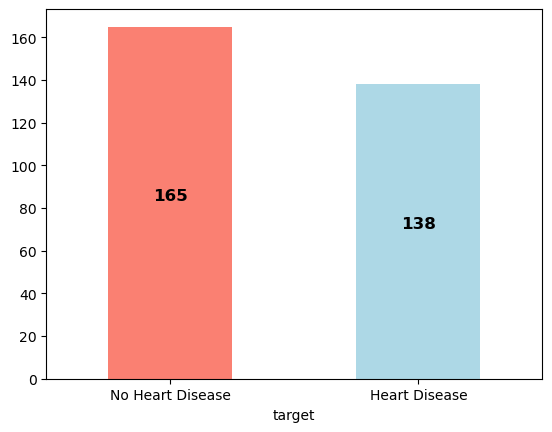

In [4]:
# Count instances in "target" column
vc = df["target"].value_counts()

# Plot class distribution
ax = vc.plot(kind="bar", color=["salmon", "lightblue"])

# Annotate bars with counts
for index, value in enumerate(vc):
    ax.text(index, value/2, str(value), ha="center", 
            va="bottom", fontsize=12, color="black", fontweight="bold")

# Set x-axis labels and display plot
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"], rotation=0)
plt.show()

In [5]:
# Dsiplay concise DataFrame summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
# Check for missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# Descriptive statistics
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency according to Sex

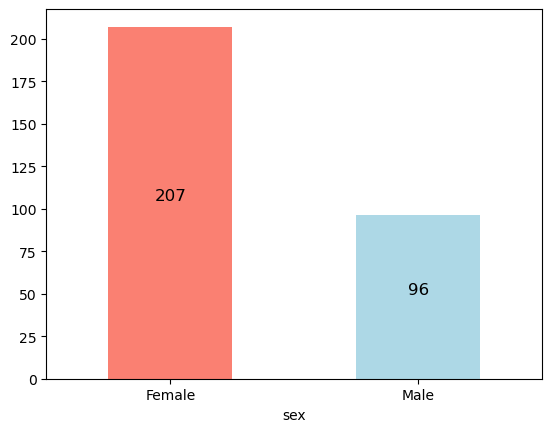

In [8]:
# Count occurences in "sex" column
sx = df["sex"].value_counts()

# Plot gender distribution
gender = sx.plot(kind="bar", color=["salmon", "lightblue"])

# Annotate bars with counts
for index, value in enumerate(sx):
    gender.text(index, value/2, str(value), ha="center", 
            va="bottom", fontsize=12, color="black")

# Set x-axis labels and display plot
plt.xticks([0, 1], ["Female", "Male"], rotation=0);

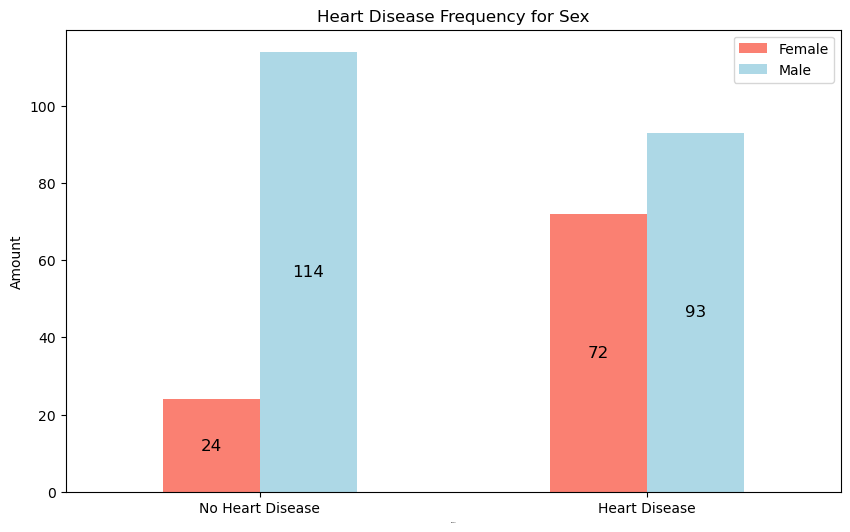

In [9]:
# Compare target vs. sex with a crosstab
sex_target =  pd.crosstab(df["target"], df["sex"])

# Plot crosstab
ax = sex_target.plot(kind="bar", figsize=(10, 6), 
                     color=["salmon", "lightblue"])

# Annotate bars with counts
for i in ax.containers:
    ax.bar_label(i, label_type="center", fontsize=12, 
                 color="black")

# Set plot title, labels, and legend
plt.title("Heart Disease Frequency for Sex")
plt.xlabel("Disease", fontsize=1)
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"], rotation=0);

### Age vs. Max Heart Rate for Heart Disease

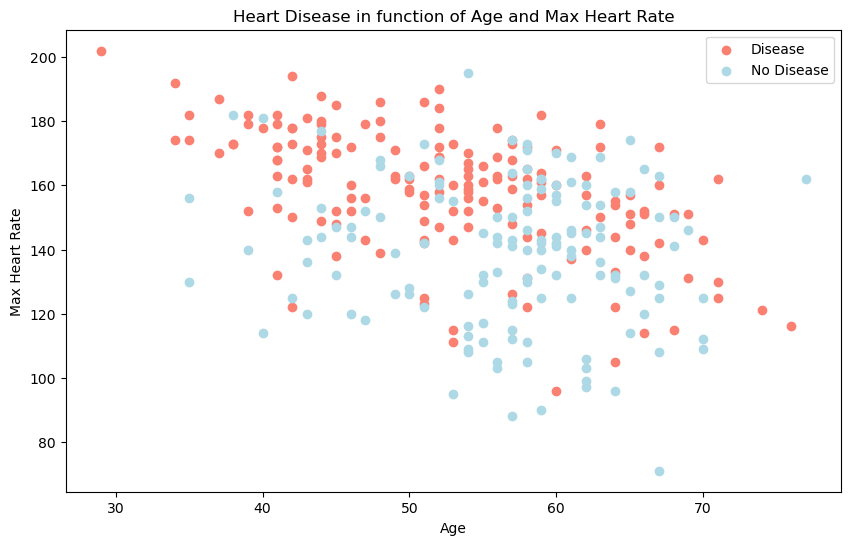

In [10]:
# Create scatter plot
plt.figure(figsize=(10, 6))

# Plot positive target
plt.scatter(df.age[df.target==1],
           df.thalach[df.target==1],
           c="salmon")

# Plot negative target
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            c="lightblue")

# Add title, labels, and legend
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);

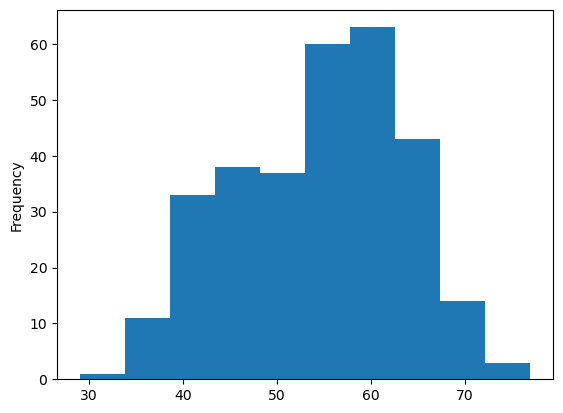

In [11]:
# Histogram of "age" distribution
df.age.plot.hist();

### Heart Disease Frequency per Chest Pain Type

cp (Chest Pain Type) Angina: a condition marked by severe pain in the chest
- 0: Typical angina: chest pain related decrease blood supply to the heart
- 1: Atypical angina: chest pain not related to heart
- 2: Non-anginal pain: typically esophageal spasms (non heart related)
- 3: Asymptomatic: chest pain not showing signs of disease

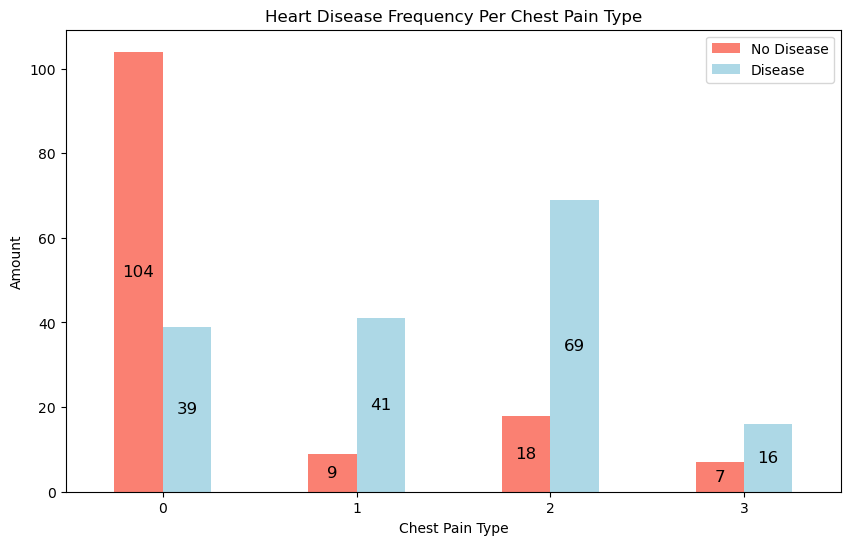

In [12]:
# Compare Chest Pain Type with target
cp_target = pd.crosstab(df.cp, df.target)

# Plot comparison
cp_target_visual = cp_target.plot(kind="bar", figsize=(10, 6), color=["salmon", "lightblue"])

# Annotate bars with counts
for i in cp_target_visual.containers:
    cp_target_visual.bar_label(i, label_type="center", fontsize=12, 
                 color="black")

# Set plot title, labels, and legend
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0);

**Let's start with making a correlation matrix**

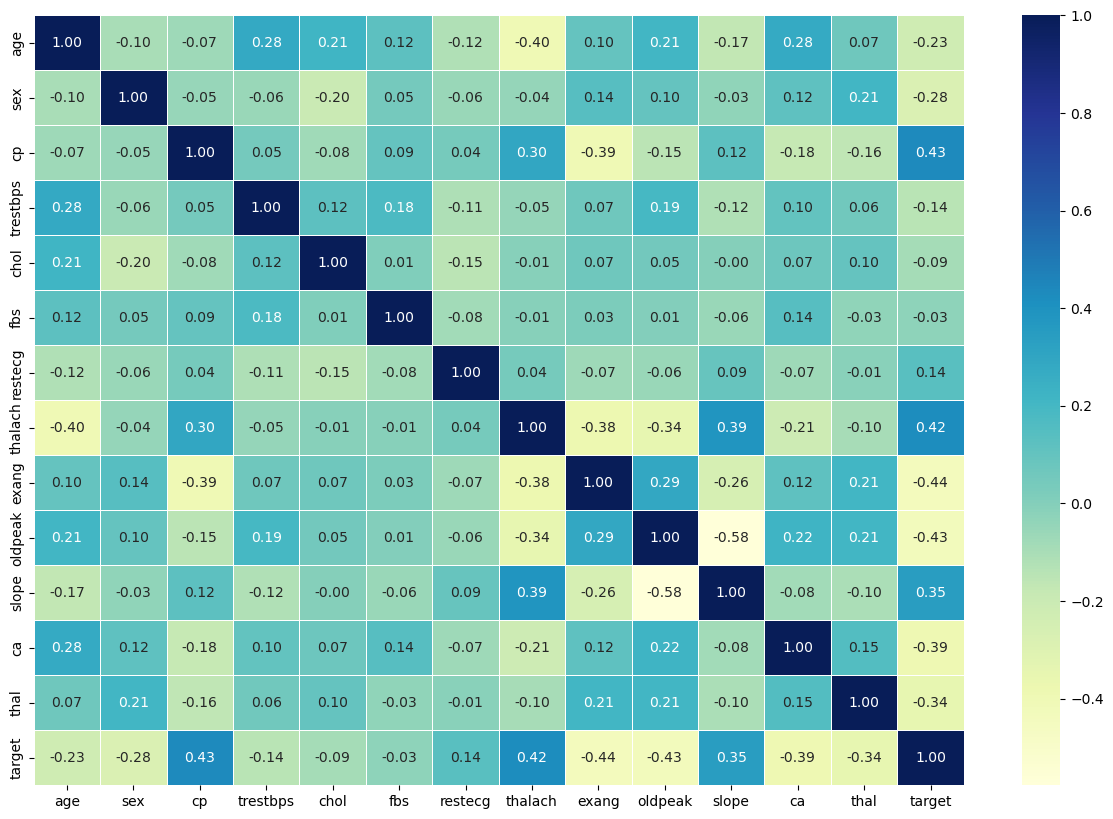

In [13]:
# Create and plot correlation matrix
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(corr_matrix, annot=True, linewidths=0.5,
                 fmt=".2f", cmap="YlGnBu");

## 5. Modeling

In [14]:
# Review our data
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [15]:
# Split data into features and labels
X = df.drop("target", axis=1)
y = df["target"]

In [16]:
# View feature data
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [17]:
# View label data
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [18]:
# Set random seed for reproducibility
np.random.seed(42)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Now that we've got our data split into training and test sets, it's time t build a machine learning model.

We'll train it (find the patterns) on the training set.

And we'll test it (use the patterns) on the test set.

We're going to try three different machine learning models, namely:

1. Logistic Regression
2. K-Nearest Neighbours Classifer
3. Random Forest Classifier

In [19]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

# Function to train and evaluate models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : dict of Scikit-Learn models
    X_train : training features
    X_test : test features
    y_train : training labels
    y_test : test labels
    """
    
    # Set random seed
    np.random.seed(42)
    
    # Make a dictionary to keep model scores
    model_scores = {}
    
    # Loop through models
    for name, model in models.items():
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [20]:
# Fit models and get scores
model_scores = fit_and_score(models=models, X_train=X_train, 
                             y_train=y_train, X_test=X_test,
                             y_test=y_test)
model_scores

{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

### Model Comparison

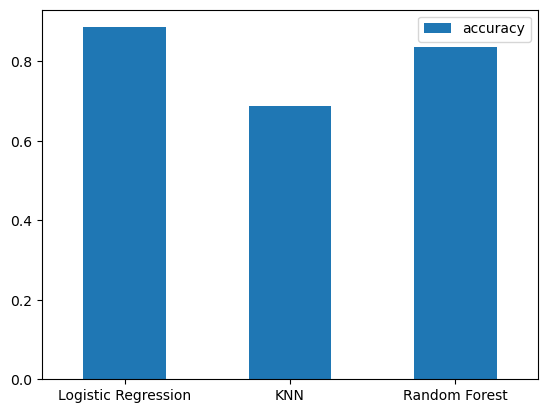

In [21]:
# Compare model accuracies
model_comparison = pd.DataFrame(model_scores, index=["accuracy"])
model_comparison.T.plot.bar()
plt.xticks(rotation=0);

Now that we've got a baseline model, and we know a model's first predictons aren't always what we should based our next steps off, what should we do?

Let's take a look at the following:
- Hyperparameter Tuning
- Feature importance
- Confusion matrix
- Cross-validation
- Precision
- Recall
- F1 score
- Classification report
- ROC curve
- Area under the curve (AUC)

### Hyperparameter Tuning

#### By hand

In [22]:
# Tune KNN by varying n_neighbors

train_scores = []
test_scores  = []

# Range of n_neighbors to test
neighbors = range(1, 21)

# Initiate KNN
knn = KNeighborsClassifier()

# Evaluate different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)
    knn.fit(X_train, y_train)    
    # Update the training score list
    train_scores.append(knn.score(X_train, y_train))    
    # Update the test scores list
    test_scores.append(knn.score(X_test, y_test))

Maximum KNN score on the test data: 75.41%


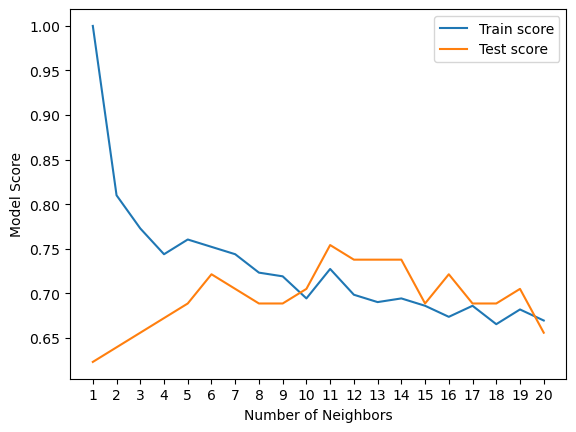

In [23]:
# Plot KNN performance
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of Neighbors")
plt.ylabel("Model Score")
plt.legend()

# Display maximum KNN test score
print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%");

### Hyperparameter tuning with RandomizedSearchCV

Tuning:
* LogisticRegression()
* RandomForestClassifier()

... using RandomizedSearchCV

In [24]:
# Hyperparameter grid for Logistic Regression
log_reg_grid = {
    "C" : np.logspace(-4, 4, 20),
    "solver" : ["liblinear"]
}

# Hyperparameter grid for Random Forest Classifier
rf_grid = {
    "n_estimators" : np.arange(10, 1000, 50),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split" : np.arange(2, 60, 2),
    "min_samples_leaf" : np.arange(2, 60, 2)
}

Now that we've got hyperparameter grids setup for each of our models, let's tune them using RandomizedSearchCV...

In [25]:
# Tune Logistic Regression using RandomizedSearchCV

np.random.seed(42)

# Setup and fit RandomizedSearchCV for Logistic Regression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5, n_iter=20, verbose=True)
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [26]:
# Get the best hyperparameters for Logistic Regression
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': 0.23357214690901212}

In [27]:
# Evaluate the best Logistic Regression model on the test set
rs_log_reg.score(X_test, y_test)

0.8852459016393442

Now that we've tune LogisticRegression(), let's do the same for RandomForestClassifier()

In [28]:
## Tune Random Forest using RandomizedSearchCV
np.random.seed(42)

# Setup and fit RandomizedSearchCV for Random Forest
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5, n_iter=20, verbose=True)
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34,
       36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34,
       36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [29]:
# Get the best hyperparameters for Random Forest
rs_rf.best_params_

{'n_estimators': 760,
 'min_samples_split': 58,
 'min_samples_leaf': 32,
 'max_depth': 10}

In [30]:
# Evaluate the best Random Forest model on the test set
rs_rf.score(X_test, y_test)

0.8688524590163934

### Hyperparameter Tuning with GridSearchCV
Since our LogisticRegression model provides the best scores so far, we'll try to improve them again using GridSearchCV...

In [31]:
# Define hyperparameters for Logistic Regression
log_reg_grid = {
    "C" : np.logspace(-4, 4, 30),
    "solver" : ["liblinear"]
}

# Setup and fit GridSearchCV for Logistic Regression
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5, verbose=True)
gs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [32]:
# Get the best hyperparameters for Logistic Regression
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [33]:
# Evaluate the best Logistic Regression model from GridSearchCV on the test set
gs_log_reg.score(X_test, y_test)

0.8852459016393442

## Evaluating our tuned machine learning classifier, beyond accuracy

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score

... and it would be great if cross-validation was used where possible.

To make comparisons and evaluate our trained model, first we need to make predictions.

In [34]:
# Predict using the tuned Logistic Regression model
y_preds = gs_log_reg.predict(X_test)

In [35]:
# View the predictions made by the tuned Logistic Regression model
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [36]:
# View the actual test labels
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

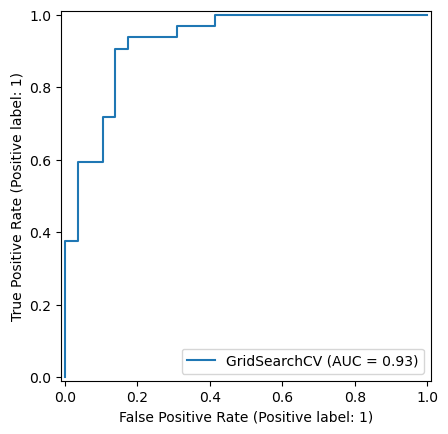

In [37]:
# Plot the ROC curve and calculate the AUC for the tuned Logistic Regression model
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test);

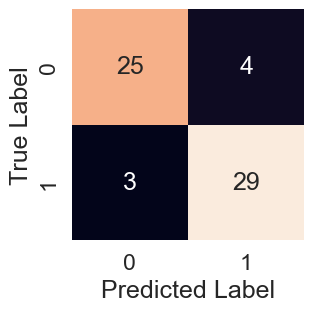

In [38]:
# Plot a confusion matrix using Seaborn
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix with Seaborn's heatmap.
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    sns.heatmap(confusion_matrix(y_test, y_preds), annot=True, cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plot_conf_mat(y_test, y_preds)


Now that we've got a ROC curve, an AUC metric and a confusion matrix, let's get a classification report as well as cross-validated precision, recall and f1-score

In [39]:
# Print classification report for model evaluation
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### Calcuate evaluation metrics using cross-validation
We're going to calculate accuracy, precision, recall and f1-score of our model using cross-validation and to do so, we'll be using 'cross_val_score()'.

In [40]:
# Output the best hyperparameters from GridSearchCV for Logistic Regression
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [41]:
# Initialize a new Logistic Regression classifier with the best parameters
clf = LogisticRegression(C=0.20433597178569418, solver="liblinear")

In [42]:
# Compute the cross-validated accuracy for the new Logistic Regression classifier
cv_acc = np.mean(cross_val_score(clf, X, y, cv=5, scoring="accuracy"))
cv_acc 

0.8446994535519124

In [43]:
# Compute the cross-validated precision for the new Logistic Regression classifier
cv_precision = np.mean(cross_val_score(clf, X, y, cv=5, scoring="precision"))
cv_precision

0.8207936507936507

In [44]:
# Compute the cross-validated recall for the new Logistic Regression classifier
cv_recall = np.mean(cross_val_score(clf, X, y, cv=5, scoring="recall"))
cv_recall

0.9212121212121213

In [45]:
# Compute the cross-validated f1-score for the new Logistic Regression classifier
cv_f1 = np.mean(cross_val_score(clf, X, y, cv=5, scoring="f1"))
cv_f1

0.8673007976269721

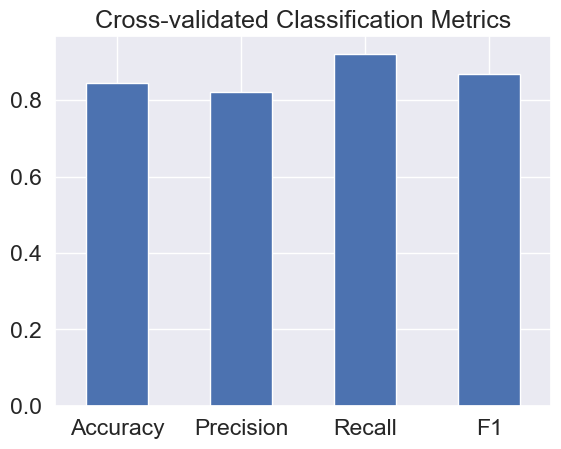

In [46]:
# Create a DataFrame for cross-validated metrics
cv_metrics = pd.DataFrame({
    "Accuracy": cv_acc,
    "Precision": cv_precision,
    "Recall": cv_recall,
    "F1": cv_f1
}, index=[0])

# Plot the metrics
cv_metrics.T.plot.bar(title="Cross-validated Classification Metrics", legend=False)
plt.xticks(rotation=False);


### Feature Importance
Feature importance is another way of asking, "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance is different for each machine learning model. One way to find feature importance is to search for "(MODEL NAME) feature importance".

Let's find the feature importance for our LogisticRegression model...

In [47]:
# Initialize and fit Logistic Regression with best parameters
clf = LogisticRegression(C=0.20433597178569418, solver="liblinear")
clf.fit(X_train, y_train);

In [48]:
# Display model coefficients
clf.coef_

array([[ 0.00316728, -0.86044619,  0.6606706 , -0.01156993, -0.00166374,
         0.04386123,  0.31275813,  0.02459361, -0.60413061, -0.56862832,
         0.45051624, -0.63609879, -0.67663383]])

In [49]:
# Review the data
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [50]:
# Map feature coefficients to their corresponding feature names
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'age': 0.0031672769574500135,
 'sex': -0.8604461876509621,
 'cp': 0.6606705956911073,
 'trestbps': -0.011569931563712749,
 'chol': -0.0016637424209784567,
 'fbs': 0.04386123481544026,
 'restecg': 0.3127581278171948,
 'thalach': 0.02459361107844528,
 'exang': -0.6041306062020464,
 'oldpeak': -0.5686283181245352,
 'slope': 0.4505162370054866,
 'ca': -0.6360987949056705,
 'thal': -0.6766338344951353}

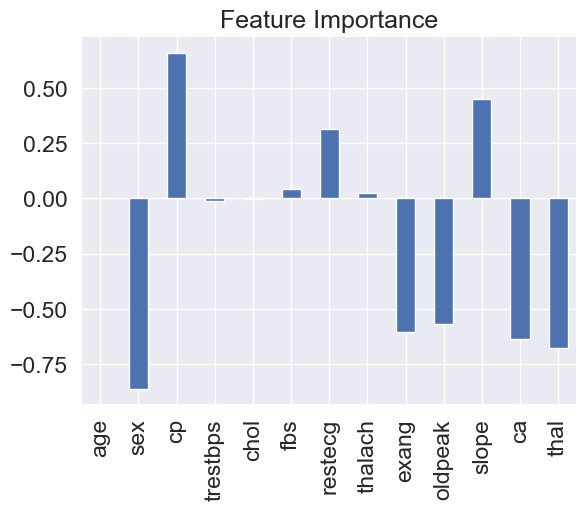

In [51]:
# Create a DataFrame for feature importance from the feature dictionary
feature_df = pd.DataFrame(feature_dict, index=[0])

# Plot the feature importance as a bar chart
feature_df.T.plot.bar(title="Feature Importance", legend=False);